# Bound in the scattered-voltage basis $V_\mathrm{sca}$ with all pointwise constraints

Same formulation as `VscatBound.ipynb` (optimization variable $x = V_\mathrm{sca} = -Z_0 I$, current eliminated by $I = -W V_\mathrm{sca}$, $W = Z_0^{-1}$),
but instead of the two global constraints and GCD, all pointwise power conservation constraints are imposed at once
through the shared projectors, as in `antenna_limits_Xmat.ipynb`:
$$\texttt{Pdiags} = \left[\,-j\,\mathbf 1_N,\ \mathbf 1_N\,\right],$$
i.e. $2N$ projectors $P' = -j\,e_i e_i^T$ and $P' = e_i e_i^T$, the imaginary and real part of
$I_i^*\left(V_i + V_{\mathrm{sca},i} - Z_s I_i\right) = 0$ for every basis function $i$.

These constraints admit every binary structure (each basis function either empty, $I_i = 0$, or material, $Z_s I_i = V_i + V_{\mathrm{sca},i}$),
and the full dipole is the optimum. The dual bound must therefore be tight, and the dual solution $x^\star$ must be the scattered voltage
of the full dipole, $V_\mathrm{sca}^\mathrm{full} = -Z_0 I^\mathrm{full}$, from which the full dipole (density $\rho = 1$) is inferred directly.

In [1]:
import numpy as np
import scipy.sparse as sp
import time
from dolphindes.cvxopt import DenseSharedProjQCQP, OptimizationHyperparameters

In [2]:
# Physical constants
epsilon_0 = 8.854e-12 # F/m
mu_0 = 4e-7 * np.pi # H/m
c = 1/np.sqrt(epsilon_0 * mu_0) # speed of light in vacuum

E0 = 1e3 # plane wave amplitude in V/m

frequency = 2.45e9 # frequency in Hz
wavelength = c / frequency # wavelength in m
print(f"Wavelength: {wavelength} m")

ka = 1 # electrical size of the antenna
k = 2 * np.pi / wavelength # wavenumber
a = ka / k # antenna circumradius
print(f"Antenna circumradius: {a} m")

omega = 2 * np.pi * frequency # angular frequency

conductivity_reduction_factor = 1 # factor to reduce conductivity for testing purposes
copper_conductivity = conductivity_reduction_factor*5.96e7 # S/m
copper_permittivity = 1 + 1j * copper_conductivity / (omega * epsilon_0) # copper permittivity in dimensionless units
print(f"Copper permittivity: {copper_permittivity:.2e}")

Wavelength: 0.1223655664053944 m
Antenna circumradius: 0.019475084757658086 m
Copper permittivity: 1.00e+00+4.37e+08j


In [3]:
# Calculate surface impedance
delta = np.sqrt(2 / (omega * mu_0 * copper_conductivity)) # skin depth in m
Zs = (1 + 1j) / (copper_conductivity * delta)
print(f"Surface impedance: {Zs} Ω")

# Load matrices from text files
Lmat = np.loadtxt(r"Lmat_dipole.txt", delimiter=',') # lossy matrix

Ndes = Lmat.shape[0] # number of design variables
print("Number of design variables: ", Ndes)

Lchol = np.linalg.cholesky(Lmat).conj().T
LcholInv = np.linalg.inv(Lchol)

def Msym(M):
    return(0.5*(M.conj().T + M))

def Mchol(M):
    return(Msym(LcholInv.conj().T @ M @ LcholInv))

R0 = np.loadtxt(r"R0_dipole.txt", delimiter=',') # radiated power matrix
R0 = Mchol(R0)

X0 = np.loadtxt(r"X0_dipole.txt", delimiter=',') # reactive power matrix
X0 = Mchol(X0)

Vinc = np.loadtxt(r"V_dipole.txt", delimiter=',') # voltage excitation vector
Vinc = E0*Vinc
def Vchol(v):
    return(LcholInv.conj().T @ v)
Vinc = Vchol(Vinc)

Zmat = Zs * np.eye(Ndes) # material impedance matrix
Z0 = R0 + 1j*X0 # free-space impedance matrix
Ztot = Z0 + Zmat # total impedance matrix

def evalObjI(Ivec):
    # radiated power in the current basis
    return(0.5*np.real(Ivec.conj().T @ R0 @ Ivec))

# full plate performance
Ifull = np.linalg.solve(Ztot, Vinc) # current distribution for full plate
Pfull = evalObjI(Ifull) # objective for full plate
print(f"Objective for full plate: {Pfull:.6e} W")

Surface impedance: (0.012739130327240646+0.012739130327240646j) Ω
Number of design variables:  195
Objective for full plate: 1.010821e+01 W


## Objective in $V_\mathrm{sca}$

With $I = -W V_\mathrm{sca}$ the radiated power $\tfrac12 I^H R_0 I$ takes the dolphindes form
$-x^H A_0 x + 2\operatorname{Re}(x^H s_0) + c_0$, $x = V_\mathrm{sca}$, with
$$A_0 = -\tfrac12 W^H R_0 W,\qquad s_0 = 0,\qquad c_0 = 0 .$$
The quadratic part is identical to the $V_\mathrm{tot}$ formulation.

In [4]:
print(f"cond(Z0) = {np.linalg.cond(Z0):.3e}")
W = np.linalg.inv(Z0)   # Z0^{-1}
WH = W.conj().T

Obj = -0.5 * Msym(WH @ R0 @ W)
obj = np.zeros(Ndes, dtype=complex)
obj0 = 0.0

def VtoI(Vsca):
    return(-W @ Vsca)

def evalObj(Vsca):
    return(-np.real(Vsca.conj().T @ Obj @ Vsca) + 2*np.real(Vsca.conj().T @ obj) + obj0)

Vfull = -Z0 @ Ifull # scattered voltage for full plate
print(f"Objective for full plate in Vsca: {evalObj(Vfull):.6e} W (I basis {Pfull:.6e} W)")

cond(Z0) = 1.750e+04
Objective for full plate in Vsca: 1.010821e+01 W (I basis 1.010821e+01 W)


## All pointwise constraints in the shared projector form

As derived in `VscatBound.ipynb`, the constraint $\operatorname{Re}\left[I^H P (V + V_\mathrm{sca} - Z_s I)\right] = 0$ with $P = \operatorname{diag}(p)$ is,
in $x = V_\mathrm{sca}$, the shared projector constraint
$\operatorname{Re}\left(-x^H A_1 P' A_2 x + 2 x^H A_2^H P'^H s_1\right) = 0$ with
$$A_1 = 1 + Z_s^* W^H,\qquad A_2 = W,\qquad s_1 = -\tfrac12 V,\qquad P' = P^H = \operatorname{diag}(p^*).$$
The columns of `Pdiags` are the diagonals of $P'$:

* $P' = e_i e_i^T$ ($p = e_i$): real power conservation $\operatorname{Re}\left[I_i^*(V + V_\mathrm{sca} - Z_s I)_i\right] = 0$ on basis function $i$,
* $P' = -j\, e_i e_i^T$ ($p = j\, e_i$): reactive power conservation $\operatorname{Im}\left[I_i^*(V + V_\mathrm{sca} - Z_s I)_i\right] = 0$ (sign flipped with respect to $q = -j$ of `VscatBound.ipynb`, irrelevant since the multipliers are free in sign).

Their span contains the global constraints of `VscatBound.ipynb` ($\sum_i$ of each block), so the bound can only be tighter.

In [5]:
A1 = np.eye(Ndes) + np.conj(Zs) * WH
A2 = W
s1 = -0.5 * Vinc

Nopt = A1.shape[0] # number of optimization variables
Pdiags = np.column_stack([
    -1j *np.eye(Nopt, dtype=complex), 
    np.eye(Nopt, dtype=complex)
])
Plist = [sp.diags(Pdiags[:, i]) for i in range(Pdiags.shape[1])]   # P' = diag(p^*)
print(f"number of projector constraints: {len(Plist)}")

def projRes(x, Pp):
    # Re(-x^H A1 P' A2 x + 2 x^H A2^H P'^H s1)
    return(np.real(-x.conj() @ A1 @ (Pp @ (A2 @ x)) + 2*x.conj() @ (A2.conj().T @ (Pp.conj().T @ s1))))

def localViolation(Vsca):
    # pointwise w_i = I_i^* (V + Vsca - Zs I)_i, zero for any physical structure
    I = VtoI(Vsca)
    return(np.conj(I)*(Vinc + Vsca - Zs*I))

def allRes(x):
    # residuals of all 2N projector constraints, vectorized: Re(conj(P'_i) w_i), w = I^* (V + Vsca - Zs I)
    return(np.real(np.conj(Pdiags) * localViolation(x)[:, None]).sum(axis=0))

# check: vectorized residuals equal the shared projector form, and vanish at the full plate
xRand = np.random.randn(Ndes) + 1j*np.random.randn(Ndes)
resRand = allRes(xRand)
print(f"random x: max |shared form - pointwise| over all constraints "
      f"{max(abs(projRes(xRand, Pp) - r) for Pp, r in zip(Plist, resRand)):.2e} (max |residual| {np.max(np.abs(resRand)):.2e})")
print(f"full plate: max |residual| over all constraints {np.max(np.abs(allRes(Vfull))):.2e}")

number of projector constraints: 390
random x: max |shared form - pointwise| over all constraints 5.55e-17 (max |residual| 2.04e-01)
full plate: max |residual| over all constraints 3.42e-12


## Dual problem

The real power multipliers $\lambda_i = 1$ (second block of `Pdiags`) reproduce the global real power constraint with $\lambda = 1 > \tfrac12$
of `VscatBound.ipynb`, which gives a dual feasible starting point.

In [6]:
QCQP = DenseSharedProjQCQP(Obj, obj, obj0, A1, s1, Plist, A2=A2, verbose=1)

lags_init = np.zeros((Pdiags.shape[1],))
lags_init[Nopt:] = 1.0   # lambda_i = 1 on all real power constraints = global real power constraint with lambda = 1
print(f"initial lags dual feasible: {QCQP.is_dual_feasible(lags_init)}")

opt_params = OptimizationHyperparameters(opttol=1e-10,
    gradConverge=True,
    min_inner_iter=10,
    max_restart=30,
    penalty_ratio=1e-3,
    penalty_reduction=0.01,
    break_iter_period=5,
    verbose=0)

t1 = time.time()
result = QCQP.solve_current_dual_problem(method='newton', init_lags=lags_init, opt_params=opt_params)
print(f"bound: {result[0]:.6e} W, full plate {Pfull:.6e} W, relative gap {(result[0]-Pfull)/Pfull:.2e}, time: {time.time()-t1:.2f}s")

Precomputed 390 A matrices and Fs vectors.


initial lags dual feasible: True


bound: 1.010821e+01 W, full plate 1.010821e+01 W, relative gap 8.51e-14, time: 15.39s


## Direct inference of the dual solution

The dual solution $x^\star = V_\mathrm{sca}^\star$ is checked against the full dipole: the current $I^\star = -W x^\star$, the primal objective,
the constraint residuals, and the inferred complex material density (as in `VscatBound.ipynb`)
$$\rho_i = \frac{Z_s I^\star_i}{V_i + V^\star_{\mathrm{sca},i}},$$
which must be $\rho = 1$ on all basis functions. Finally the structure with the inferred (real, clipped) density is solved physically.

In [7]:
lags = QCQP.current_lags
print(f"minimum eigenvalue of A: {np.min(np.linalg.eigvalsh(Msym(QCQP._get_total_A(lags)))):.3e}")

Vstar = QCQP.current_xstar
Istar = VtoI(Vstar)
print(f"dual bound {QCQP.current_dual:.6e} W, P(x*) {evalObj(Vstar):.6e} W (I basis {evalObjI(Istar):.6e} W), full plate {Pfull:.6e} W")
print(f"relative difference to full plate: Vsca {np.linalg.norm(Vstar - Vfull)/np.linalg.norm(Vfull):.2e}, "
      f"I {np.linalg.norm(Istar - Ifull)/np.linalg.norm(Ifull):.2e}")
print(f"max |constraint residual| at x*: {np.max(np.abs(allRes(Vstar))):.2e}, "
      f"||local violation|| {np.linalg.norm(localViolation(Vstar)):.2e} (||I*^* (V + Vsca*)|| {np.linalg.norm(np.conj(Istar)*(Vinc + Vstar)):.2e})")

def complexDensity(Vsca):
    # inferred complex material density rho = Zs I / (V + Vsca) (Cholesky space)
    return Zs*VtoI(Vsca)/(Vinc + Vsca)

def realizedObj(rho):
    # radiated power of the structure with density rho: (Zs + diag(rho) Z0) I = diag(rho) V
    S = np.diag(rho.astype(complex))
    I = np.linalg.solve(Zs*np.eye(Ndes) + S @ Z0, S @ Vinc)
    return evalObjI(I)

rho = complexDensity(Vstar)
print(f"inferred density: max |rho - 1| {np.max(np.abs(rho - 1)):.2e}, "
      f"Re rho in [{rho.real.min():.6f}, {rho.real.max():.6f}], Im rho in [{rho.imag.min():.2e}, {rho.imag.max():.2e}]")
rhoReal = np.clip(rho.real, 0, 1)
print(f"realized objective of inferred density: {realizedObj(rhoReal):.6e} W (full plate {Pfull:.6e} W, dual bound {QCQP.current_dual:.6e} W)")

minimum eigenvalue of A: 1.094e-06
dual bound 1.010821e+01 W, P(x*) 1.010821e+01 W (I basis 1.010821e+01 W), full plate 1.010821e+01 W
relative difference to full plate: Vsca 1.14e-05, I 8.33e-10
max |constraint residual| at x*: 6.65e-06, ||local violation|| 2.43e-05 (||I*^* (V + Vsca*)|| 2.62e-02)
inferred density: max |rho - 1| 2.26e-03, Re rho in [0.998392, 1.001551], Im rho in [-1.59e-03, 1.53e-03]
realized objective of inferred density: 1.010818e+01 W (full plate 1.010821e+01 W, dual bound 1.010821e+01 W)


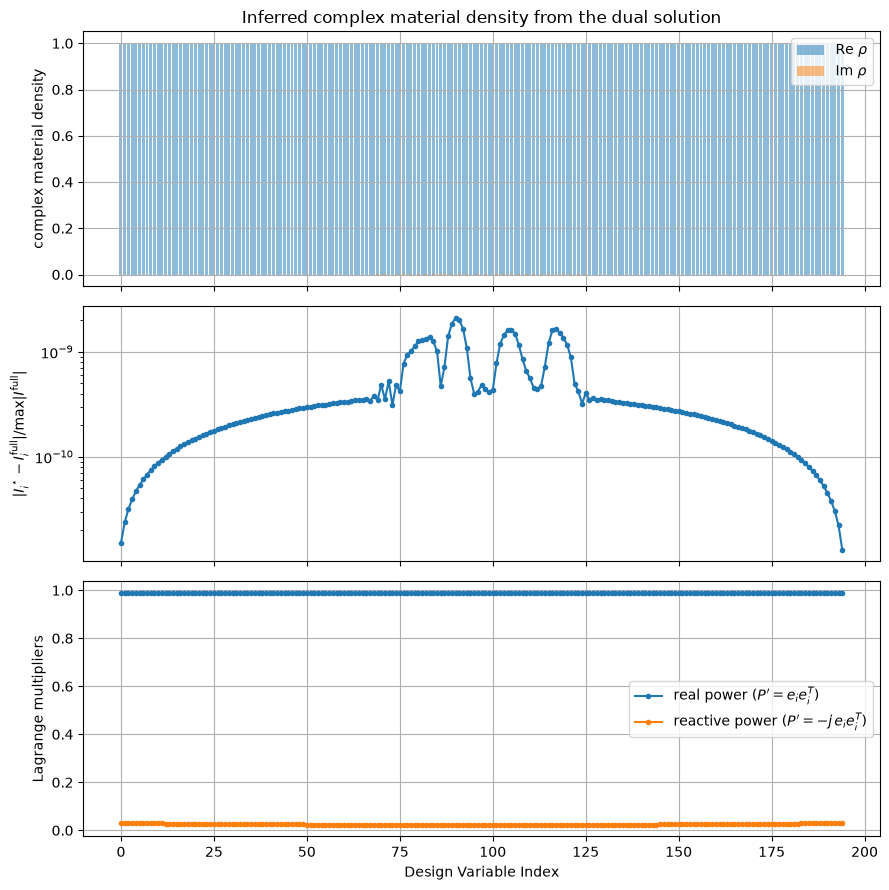

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)
axes[0].bar(np.arange(Ndes), np.real(rho), alpha=0.5, label=r'Re $\rho$')
axes[0].bar(np.arange(Ndes), np.imag(rho), alpha=0.5, label=r'Im $\rho$')
axes[0].set_ylabel('complex material density'); axes[0].set_title('Inferred complex material density from the dual solution')
axes[0].legend(); axes[0].grid(True)
axes[1].semilogy(np.arange(Ndes), np.abs(Istar - Ifull)/np.max(np.abs(Ifull)), '.-')
axes[1].set_ylabel(r'$|I^\star_i - I^\mathrm{full}_i| / \max|I^\mathrm{full}|$'); axes[1].grid(True)
axes[2].plot(np.arange(Ndes), lags[Nopt:], '.-', label=r'real power ($P^\prime = e_i e_i^T$)')
axes[2].plot(np.arange(Ndes), lags[:Nopt], '.-', label=r'reactive power ($P^\prime = -j\, e_i e_i^T$)')
axes[2].set_ylabel('Lagrange multipliers'); axes[2].legend(); axes[2].grid(True)
axes[-1].set_xlabel('Design Variable Index')
plt.tight_layout(); plt.show()

## Comparison: global constraints + 20 GCD iterations

As in `VscatBound.ipynb`, starting from the global real ($P' = \mathbf 1$) and reactive ($P' = j\mathbf 1$) power constraints,
`run_gcd` adds two projectors per iteration (strongest local violation and minimal eigenvalue). The result is compared with the
all-pointwise solution above, including the final Lagrangian matrices
$$A(\lambda) = A_0 + \sum_k \lambda_k \operatorname{Sym}\left(A_1 P'_k A_2\right),$$
through $\|A_\mathrm{GCD} - A_\mathrm{full}\|_F / \|A_\mathrm{full}\|_F$. Since every GCD projector is diagonal, it lies in the span of the pointwise
projectors, so $A_\mathrm{GCD}$ is a feasible point of the all-pointwise dual and $A_\mathrm{GCD} \to A_\mathrm{full}$ as the GCD bound approaches the tight bound.

In [9]:
import copy
from dolphindes.cvxopt.gcd import GCDHyperparameters

Ngcd = 20   # number of GCD iterations, each adds a max violation and a min eigenvalue projector

PlistGlob = [sp.diags(q*np.ones(Ndes, dtype=complex)) for q in [1, 1j]]   # global real and reactive power, P' = 1 and j 1
gQCQP = DenseSharedProjQCQP(Obj, obj, obj0, A1, s1, PlistGlob, A2=A2, verbose=0)
gcd_opt_params = OptimizationHyperparameters(opttol=1e-6,
    gradConverge=True,
    min_inner_iter=10,
    max_restart=10,
    penalty_ratio=1e-2,
    penalty_reduction=0.1,
    break_iter_period=5,
    verbose=0)
gQCQP.solve_current_dual_problem(method='newton', init_lags=np.array([1.0, 0.0]), opt_params=gcd_opt_params)
dualGlob = gQCQP.current_dual

gcd_params = GCDHyperparameters(max_proj_cstrt_num=2 + 2*Ngcd,
    max_gcd_iter_num=Ngcd,
    gcd_iter_period=Ngcd + 1,   # no early termination
    opt_params=gcd_opt_params)

t1 = time.time()
gQCQP.run_gcd(gcd_params)
print(f"bound: global {dualGlob:.6e} -> GCD {gQCQP.current_dual:.6e} W, all pointwise {QCQP.current_dual:.6e} W, full plate {Pfull:.6e} W, "
      f"{gQCQP.n_proj_constr} projectors, {time.time()-t1:.2f}s")

At GCD iteration #1, best dual bound found is             10.120932760127522.
min eigenvalue: 1.812903e-06
At GCD iteration #2, best dual bound found is             10.113198452266072.
min eigenvalue: 1.421461e-06
At GCD iteration #3, best dual bound found is             10.113175883313806.


min eigenvalue: 1.420208e-06
At GCD iteration #4, best dual bound found is             10.112937261561653.
min eigenvalue: 1.408314e-06


At GCD iteration #5, best dual bound found is             10.111878757848812.
min eigenvalue: 1.353023e-06
At GCD iteration #6, best dual bound found is             10.111399197542562.
min eigenvalue: 1.326256e-06


At GCD iteration #7, best dual bound found is             10.11102548808965.
min eigenvalue: 1.304832e-06
At GCD iteration #8, best dual bound found is             10.11087942420364.
min eigenvalue: 1.296015e-06


At GCD iteration #9, best dual bound found is             10.110797308707184.
min eigenvalue: 1.290925e-06
At GCD iteration #10, best dual bound found is             10.110717969519042.
min eigenvalue: 1.285728e-06


...

At GCD iteration #17, best dual bound found is             10.109552192013322.
min eigenvalue: 1.200868e-06


At GCD iteration #18, best dual bound found is             10.109461324915666.
min eigenvalue: 1.194138e-06


At GCD iteration #19, best dual bound found is             10.109387297875712.
min eigenvalue: 1.188699e-06


At GCD iteration #20, best dual bound found is             10.109326220839156.
min eigenvalue: 1.184154e-06


At GCD iteration #21, best dual bound found is             10.109273741959642.
bound: global 1.012093e+01 -> GCD 1.010927e+01 W, all pointwise 1.010821e+01 W, full plate 1.010821e+01 W, 42 projectors, 4.41s


In [10]:
Afull = Msym(QCQP._get_total_A(QCQP.current_lags))      # all pointwise constraints
Agcd = Msym(gQCQP._get_total_A(gQCQP.current_lags))     # global + Ngcd GCD iterations
Aglob = Msym(A1 @ A2 - Obj)                              # global real power constraint with lambda = 1 (initial point)
relErr = lambda A: np.linalg.norm(A - Afull)/np.linalg.norm(Afull)
print(f"||A_GCD - A_full||_F / ||A_full||_F = {relErr(Agcd):.3e} (initial A: {relErr(Aglob):.3e})")
print(f"spectral norm: ||A_GCD - A_full||_2 / ||A_full||_2 = {np.linalg.norm(Agcd - Afull, 2)/np.linalg.norm(Afull, 2):.3e}")
print(f"minimum eigenvalue of A: GCD {np.min(np.linalg.eigvalsh(Agcd)):.3e}, all pointwise {np.min(np.linalg.eigvalsh(Afull)):.3e}")

# GCD multipliers as pointwise multipliers: sum_k lambda_k P'_k = diag(Pdiags @ lags) projected on the pointwise basis
PgcdSum = gQCQP.Proj.get_Pdata_column_stack() @ gQCQP.current_lags[:gQCQP.n_proj_constr]
lagsGcdPw = np.concatenate([-np.imag(PgcdSum), np.real(PgcdSum)])   # P'_sum = -j lam_im + lam_re  ->  [lam_im, lam_re]
print(f"pointwise multipliers: ||lags_GCD - lags_full|| / ||lags_full|| = "
      f"{np.linalg.norm(lagsGcdPw - QCQP.current_lags)/np.linalg.norm(QCQP.current_lags):.3e}")
print(f"check: A from mapped GCD multipliers vs A_GCD: {np.linalg.norm(Msym(QCQP._get_total_A(lagsGcdPw)) - Agcd)/np.linalg.norm(Agcd):.2e}")

VstarG = gQCQP.current_xstar
print(f"dual solution vs full plate: Vsca {np.linalg.norm(VstarG - Vfull)/np.linalg.norm(Vfull):.3e} (all pointwise "
      f"{np.linalg.norm(Vstar - Vfull)/np.linalg.norm(Vfull):.3e}), "
      f"I {np.linalg.norm(VtoI(VstarG) - Ifull)/np.linalg.norm(Ifull):.3e} (all pointwise {np.linalg.norm(Istar - Ifull)/np.linalg.norm(Ifull):.3e})")
rhoG = complexDensity(VstarG)
print(f"inferred density GCD: max |rho - 1| {np.max(np.abs(rhoG - 1)):.3e}, "
      f"realized objective of clipped Re rho {realizedObj(np.clip(rhoG.real, 0, 1)):.6e} W")

||A_GCD - A_full||_F / ||A_full||_F = 2.604e-04 (initial A: 2.021e+00)
spectral norm: ||A_GCD - A_full||_2 / ||A_full||_2 = 1.840e-04
minimum eigenvalue of A: GCD 1.180e-06, all pointwise 1.094e-06
pointwise multipliers: ||lags_GCD - lags_full|| / ||lags_full|| = 1.752e-03
check: A from mapped GCD multipliers vs A_GCD: 1.24e-15
dual solution vs full plate: Vsca 1.662e+00 (all pointwise 1.137e-05), I 2.417e-03 (all pointwise 8.331e-10)
inferred density GCD: max |rho - 1| 1.103e+00, realized objective of clipped Re rho 4.425179e-07 W


### Lagrange vectors

The dual solution is $x^\star = A(\lambda)^{-1} S(\lambda)$ with the Lagrange vector (linear term of the Lagrangian)
$$S(\lambda) = s_0 + A_2^H \sum_k \lambda_k P_k'^H s_1 .$$
The difference of the dual solutions splits exactly into the contributions of the vector and of the matrix error,
$$x_\mathrm{GCD} - x_\mathrm{full} = A_\mathrm{GCD}^{-1}\left(S_\mathrm{GCD} - S_\mathrm{full}\right) - A_\mathrm{GCD}^{-1}\left(A_\mathrm{GCD} - A_\mathrm{full}\right) x_\mathrm{full},$$
and both are amplified by $A_\mathrm{GCD}^{-1}$, mostly along the eigenvectors with the smallest eigenvalues.

||S_GCD - S_full|| / ||S_full|| = 1.791e-03 (initial S: 2.693e-02)
check: S from mapped GCD multipliers vs S_GCD: 4.51e-16
check: x* = A^-1 S: all pointwise 9.81e-12, GCD 4.55e-12
||x_GCD - x_full|| / ||x_full|| = 1.662e+00: vector part 1.079e-02, matrix part 1.662e+00, split residual 1.31e-11
eigenvalues of A_GCD in [1.180e-06, 4.195e-01], 170 of 195 below 10 x the minimum
share of ||A_GCD^-1 (.)||^2 in this cluster: vector part 0.3679, matrix part 0.5898


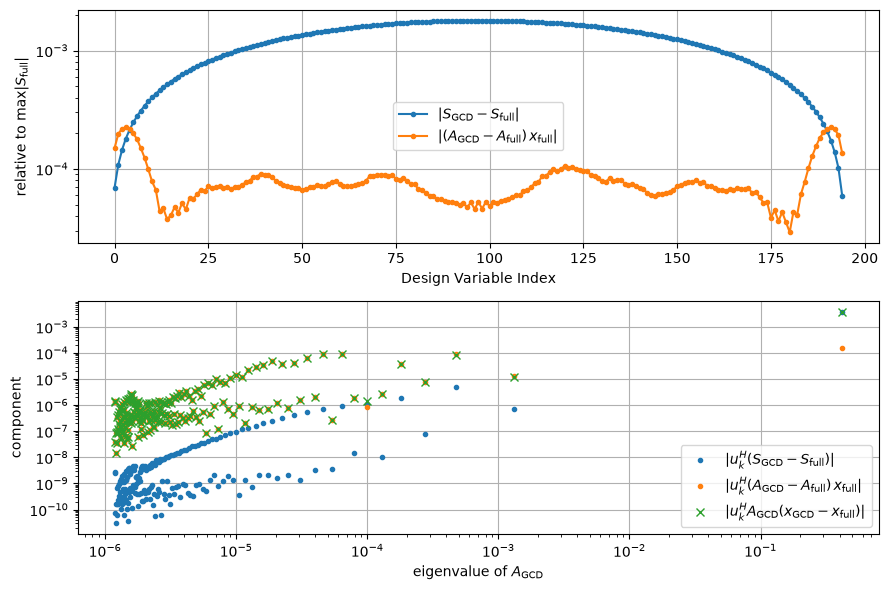

In [11]:
Sfull = QCQP._get_total_S(QCQP.current_lags)
Sgcd = gQCQP._get_total_S(gQCQP.current_lags)
Sglob = A2.conj().T @ s1  # global real power constraint with lambda = 1 (initial point)
relErrS = lambda S: np.linalg.norm(S - Sfull)/np.linalg.norm(Sfull)
print(f"||S_GCD - S_full|| / ||S_full|| = {relErrS(Sgcd):.3e} (initial S: {relErrS(Sglob):.3e})")
print(f"check: S from mapped GCD multipliers vs S_GCD: {np.linalg.norm(QCQP._get_total_S(lagsGcdPw) - Sgcd)/np.linalg.norm(Sgcd):.2e}")
print(f"check: x* = A^-1 S: all pointwise {np.linalg.norm(np.linalg.solve(Afull, Sfull) - Vstar)/np.linalg.norm(Vstar):.2e}, "
      f"GCD {np.linalg.norm(np.linalg.solve(Agcd, Sgcd) - VstarG)/np.linalg.norm(VstarG):.2e}")

# split of the dual solution error into the Lagrange vector and Lagrange matrix contributions
dxS = np.linalg.solve(Agcd, Sgcd - Sfull)
dxA = -np.linalg.solve(Agcd, (Agcd - Afull) @ Vstar)
dx = VstarG - Vstar
nV = np.linalg.norm(Vstar)
print(f"||x_GCD - x_full|| / ||x_full|| = {np.linalg.norm(dx)/nV:.3e}: "
      f"vector part {np.linalg.norm(dxS)/nV:.3e}, matrix part {np.linalg.norm(dxA)/nV:.3e}, "
      f"split residual {np.linalg.norm(dx - dxS - dxA)/nV:.2e}")

# error components in the eigenbasis of A_GCD
evG, UG = np.linalg.eigh(Agcd)
cS, cA = UG.conj().T @ (Sgcd - Sfull), UG.conj().T @ ((Agcd - Afull) @ Vstar)
low = evG < 10*evG[0]   # low-eigenvalue cluster of A_GCD
print(f"eigenvalues of A_GCD in [{evG[0]:.3e}, {evG[-1]:.3e}], {np.sum(low)} of {Ndes} below 10 x the minimum")
print(f"share of ||A_GCD^-1 (.)||^2 in this cluster: "
      f"vector part {np.sum(np.abs(cS[low]/evG[low])**2)/np.sum(np.abs(cS/evG)**2):.4f}, "
      f"matrix part {np.sum(np.abs(cA[low]/evG[low])**2)/np.sum(np.abs(cA/evG)**2):.4f}")

fig, axes = plt.subplots(2, 1, figsize=(9, 6))
axes[0].semilogy(np.arange(Ndes), np.abs(Sgcd - Sfull)/np.max(np.abs(Sfull)), '.-', label=r'$|S_\mathrm{GCD} - S_\mathrm{full}|$')
axes[0].semilogy(np.arange(Ndes), np.abs((Agcd - Afull) @ Vstar)/np.max(np.abs(Sfull)), '.-', label=r'$|(A_\mathrm{GCD} - A_\mathrm{full})\, x_\mathrm{full}|$')
axes[0].set_xlabel('Design Variable Index'); axes[0].set_ylabel(r'relative to $\max|S_\mathrm{full}|$'); axes[0].legend(); axes[0].grid(True)
axes[1].loglog(evG, np.abs(cS), '.', label=r'$|u_k^H (S_\mathrm{GCD} - S_\mathrm{full})|$')
axes[1].loglog(evG, np.abs(cA), '.', label=r'$|u_k^H (A_\mathrm{GCD} - A_\mathrm{full})\, x_\mathrm{full}|$')
axes[1].loglog(evG, np.abs(cS - cA), 'x', label=r'$|u_k^H A_\mathrm{GCD}(x_\mathrm{GCD} - x_\mathrm{full})|$')
axes[1].set_xlabel(r'eigenvalue of $A_\mathrm{GCD}$'); axes[1].set_ylabel('component'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()

A_full: eigenvalues in [1.094e-06, 4.195e-01], cond 3.836e+05
A_GCD:  eigenvalues in [1.180e-06, 4.195e-01], cond 3.554e+05
max relative eigenvalue difference |ev_GCD - ev_full|/ev_full: 7.970e-02


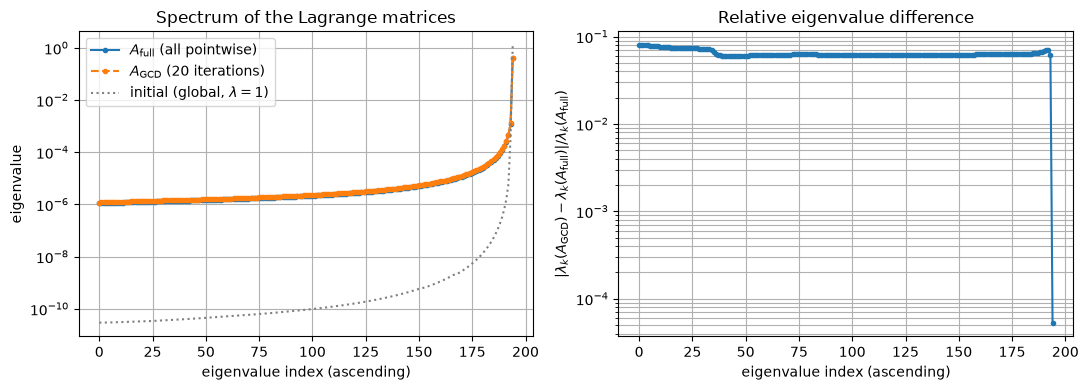

In [12]:
# spectra of the Lagrange matrices
evFull = np.linalg.eigvalsh(Afull)
evInit = np.linalg.eigvalsh(Aglob)
print(f"A_full: eigenvalues in [{evFull[0]:.3e}, {evFull[-1]:.3e}], cond {evFull[-1]/evFull[0]:.3e}")
print(f"A_GCD:  eigenvalues in [{evG[0]:.3e}, {evG[-1]:.3e}], cond {evG[-1]/evG[0]:.3e}")
print(f"max relative eigenvalue difference |ev_GCD - ev_full|/ev_full: {np.max(np.abs(evG - evFull)/evFull):.3e}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].semilogy(np.arange(Ndes), evFull, '.-', label=r'$A_\mathrm{full}$ (all pointwise)')
axes[0].semilogy(np.arange(Ndes), evG, '.--', label=fr'$A_\mathrm{{GCD}}$ ({Ngcd} iterations)')
axes[0].semilogy(np.arange(Ndes), evInit, ':', c='gray', label=r'initial (global, $\lambda = 1$)')
axes[0].set_xlabel('eigenvalue index (ascending)'); axes[0].set_ylabel('eigenvalue'); axes[0].set_title('Spectrum of the Lagrange matrices')
axes[0].legend(); axes[0].grid(True, which='both')
axes[1].semilogy(np.arange(Ndes), np.abs(evG - evFull)/evFull, '.-')
axes[1].set_xlabel('eigenvalue index (ascending)'); axes[1].set_ylabel(r'$|\lambda_k(A_\mathrm{GCD}) - \lambda_k(A_\mathrm{full})| / \lambda_k(A_\mathrm{full})$')
axes[1].set_title('Relative eigenvalue difference'); axes[1].grid(True, which='both')
plt.tight_layout(); plt.show()

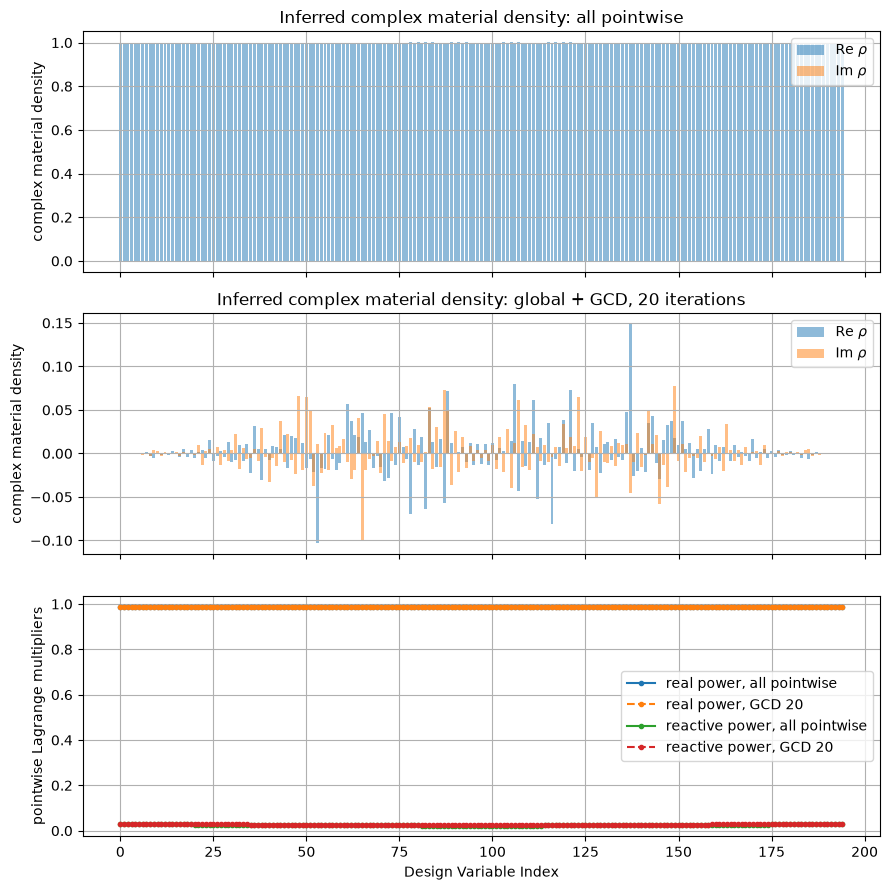

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)
for ax, (name, r) in zip(axes[:2], [("all pointwise", rho), (f"global + GCD, {Ngcd} iterations", rhoG)]):
    ax.bar(np.arange(Ndes), np.real(r), alpha=0.5, label=r'Re $\rho$')
    ax.bar(np.arange(Ndes), np.imag(r), alpha=0.5, label=r'Im $\rho$')
    ax.set_ylabel('complex material density'); ax.set_title(f'Inferred complex material density: {name}')
    ax.legend(); ax.grid(True)
axes[2].plot(np.arange(Ndes), lags[Nopt:], '.-', label='real power, all pointwise')
axes[2].plot(np.arange(Ndes), lagsGcdPw[Nopt:], '.--', label=f'real power, GCD {Ngcd}')
axes[2].plot(np.arange(Ndes), lags[:Nopt], '.-', label='reactive power, all pointwise')
axes[2].plot(np.arange(Ndes), lagsGcdPw[:Nopt], '.--', label=f'reactive power, GCD {Ngcd}')
axes[2].set_ylabel('pointwise Lagrange multipliers'); axes[2].legend(); axes[2].grid(True)
axes[-1].set_xlabel('Design Variable Index')
plt.tight_layout(); plt.show()